# Laboratorul 8 -> Text Mining

Cerinta: Stabilirea emotiilor dintr-un text

Exemplu de text pe care sa se ruleze analiza:
By choosing a bike over a car, I’m reducing my environmental footprint. Cycling promotes eco-friendly transportation, and I’m proud to be part of that movement.

Metoda utilizata: Crearea unui clasificator bazat pe un ANN (folosind cod propriu)




Proces:

1. Se pleaca de la un set de date format din textul mesajelor.
2. Se imparte setul de date in date de antrenament si in date de test.
3. Se extrag anumite caracteristici din textul mesajelor folosind diferite reprezentari precum:
    - Bag of Words
    - TF-IDF
    - Word2Vec
4. Invatare model
5. Calcul metrici de performanta


In [37]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Pasul 1 + 2 - incarcarea datelor si separarea in seturi de date de antrenament, respectiv test

In [38]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("reviews_mixed.csv")

# pentru a avea un set echilibrat si de test si de antrenament
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Sentiment']
)

# nu se vor numerota randurile (index = False)
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

Incarcarea datelor de antrenament

In [39]:
crtDir =  os.getcwd()
fileTrain = os.path.join(crtDir, '', 'train.csv')
fileTest = os.path.join(crtDir, '', 'test.csv')

dataTrain = []
with open(fileTrain) as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        if line_count == 0:
            dataNames = row
        else:
            dataTrain.append(row)
        line_count += 1

trainInputs = [dataTrain[i][0] for i in range(len(dataTrain))]
trainOutputs = [dataTrain[i][1] for i in range(len(dataTrain))]
labelNames = list(set(trainOutputs))

print(trainInputs[:2])
print(trainOutputs[:2])
print(labelNames[:2])

["It's much more powerful and pleasant than any liquid_fabric_softener scents ", 'Lift was a bit of a pain with card access.']
['positive', 'negative']
['positive', 'negative']


Incarcarea datelor de test

In [40]:
dataTest = []
with open(fileTest) as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        if line_count == 0:
            dataNames = row
        else:
            dataTest.append(row)
        line_count += 1

testInputs = [dataTest[i][0] for i in range(len(dataTest))]
testOutputs = [dataTest[i][1] for i in range(len(dataTest))]

Verificarea distribuirii datelor de antrenament

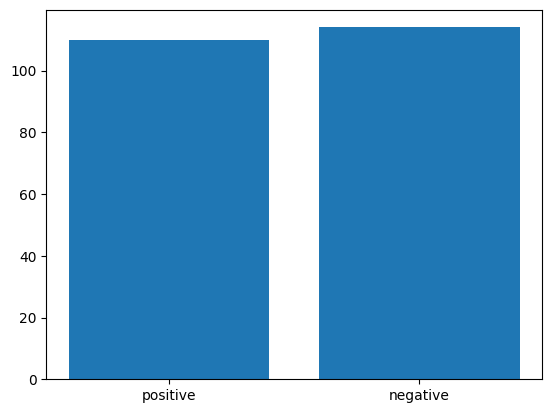

In [41]:
bins = range(3)
plt.hist(trainOutputs, bins, rwidth = 0.8)
bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
plt.xticks(np.arange(min(bins)+bin_w/2, max(bins), bin_w), labelNames)
plt.show()

### Pasul 3 - extragerea caracteristicilor

Reprezentare 1 -> BoW (Bag of Words)

Ce identifica in principal?
Prezenta cuvintelor in mesaj

In [42]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(binary=True)

# vom da fit numai pe setul de date de antrenament, pentru a crea vocabularul
# datele din setul de test vrem sa foloseasca acelasi vocabular, asa ca doar vom transforma mesajele pe baza vocabularului deja existent
trainFeatures1 = vectorizer.fit_transform(trainInputs)
testFeatures1 = vectorizer.transform(testInputs)

# transformarea matricelor in vectori (aplatizare)
trainFeatures1_dense = trainFeatures1.toarray()
testFeatures1_dense = testFeatures1.toarray()


print("vocab size: ", len(vectorizer.vocabulary_),  " words")
print("traindata size: ", len(trainInputs), " messages")
print("trainFeatures shape: ", trainFeatures1.shape)

vocab size:  629  words
traindata size:  224  messages
trainFeatures shape:  (224, 629)


Reprezentare 2 -> TF - IDF (Term Frequency - Inverse Document Frequency)

Ce identifica in principal?
Importanta cuvintelor

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

# indiferent de cate cuvinte distincte exista in setul de date, vocabularul le va retine pe primele 50 cele mai importante
vectorizer = TfidfVectorizer(max_features=50)

# vom da fit numai pe setul de date de antrenament, pentru a crea vocabularul
# datele din setul de test vrem sa foloseasca acelasi vocabular, asa ca doar vom transforma mesajele pe baza vocabularului deja existent
trainFeatures2 = vectorizer.fit_transform(trainInputs)
testFeatures2 = vectorizer.transform(testInputs)

# transformarea matricelor in vectori (aplatizare)
trainFeatures2_dense = trainFeatures2.toarray()
testFeatures2_dense = testFeatures2.toarray()

# vocabbulary from the train data
print('vocab: ', vectorizer.get_feature_names_out()[:10])
print('features: ', trainFeatures2.toarray()[:3])

vocab:  ['air' 'all' 'and' 'are' 'as' 'at' 'bathroom' 'bed' 'clean' 'coffee']
features:  [[0.         0.         0.54294465 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.83976849
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.65236267 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0. 

Reprezentarea 3 -> word2vec

Ce identifica in principal?
Contextul si relatia dintre cuvinte

In [44]:
import gensim

# Google's pre-trained Word2Vec
crtDir =  os.getcwd()
modelPath = os.path.join(crtDir, '', 'GoogleNews-vectors-negative300.bin')

word2vecModel300 = gensim.models.KeyedVectors.load_word2vec_format(modelPath, binary=True)
print(word2vecModel300.most_similar('support'))

[('supporting', 0.6251285076141357), ('suport', 0.6071150302886963), ('suppport', 0.6053199768066406), ('Support', 0.6044272780418396), ('supported', 0.6009396314620972), ('backing', 0.6007589101791382), ('supports', 0.5269277691841125), ('assistance', 0.5207138061523438), ('sup_port', 0.5192490220069885), ('supportive', 0.5110024809837341)]


In [45]:
def featureComputation(model, data):
    features = []
    phrases = [ phrase.split() for phrase in data]
    for phrase in phrases:
        # compute the embeddings of all the words from a phrase (words of more than 2 characters) known by the model
        vectors = [model[word] for word in phrase if (len(word) > 2) and (word in model.index_to_key)]
        if len(vectors) == 0:
            result = [0.0] * model.vector_size
        else:
            result = np.sum(vectors, axis=0) / len(vectors)
        features.append(result)
    return features

trainFeatures3 = featureComputation(word2vecModel300, trainInputs)
testFeatures3 = featureComputation(word2vecModel300, testInputs)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# normalizarea valorilor
trainFeatures3_scaled = scaler.fit_transform(trainFeatures3)
testFeatures3_scaled = scaler.transform(testFeatures3)

### Pasul 4 - antrenarea modelului

In [46]:
from ANN import ANN
trainOutputsBinary = [1 if example == 'negative' else 0 for example in trainOutputs]

classifier = ANN(itterations=300 ,layers=1,neurons=[30],learningRate=.01)
classifier.fit(trainFeatures3, trainOutputsBinary)

Iteratia 1, Loss: 0.1297278002
Iteratia 2, Loss: 0.1271733758
Iteratia 3, Loss: 0.1254169498
Iteratia 4, Loss: 0.1241611083
Iteratia 5, Loss: 0.1232034365
Iteratia 6, Loss: 0.1223750694
Iteratia 7, Loss: 0.1216054048
Iteratia 8, Loss: 0.1208933676
Iteratia 9, Loss: 0.1201984378
Iteratia 10, Loss: 0.1195079386
Iteratia 11, Loss: 0.1188320088
Iteratia 12, Loss: 0.1181427848
Iteratia 13, Loss: 0.1174654236
Iteratia 14, Loss: 0.1167821907
Iteratia 15, Loss: 0.1160887155
Iteratia 16, Loss: 0.1153599154
Iteratia 17, Loss: 0.1145989430
Iteratia 18, Loss: 0.1138470305
Iteratia 19, Loss: 0.1130755943
Iteratia 20, Loss: 0.1122695112
Iteratia 21, Loss: 0.1114478319
Iteratia 22, Loss: 0.1106112726
Iteratia 23, Loss: 0.1096953935
Iteratia 24, Loss: 0.1088933790
Iteratia 25, Loss: 0.1079843351
Iteratia 26, Loss: 0.1070411454
Iteratia 27, Loss: 0.1060600010
Iteratia 28, Loss: 0.1051108803
Iteratia 29, Loss: 0.1041220763
Iteratia 30, Loss: 0.1030923516
Iteratia 31, Loss: 0.1020575913
Iteratia 32, Loss

### Pasul 5 - testarea modelului

In [47]:
computedTestResults = classifier.predict(testFeatures3)
computedTestOutputs = ['negative' if result >= 0.5 else 'positive' for result in computedTestResults]

### Pasul 6 - Metrici de performanta

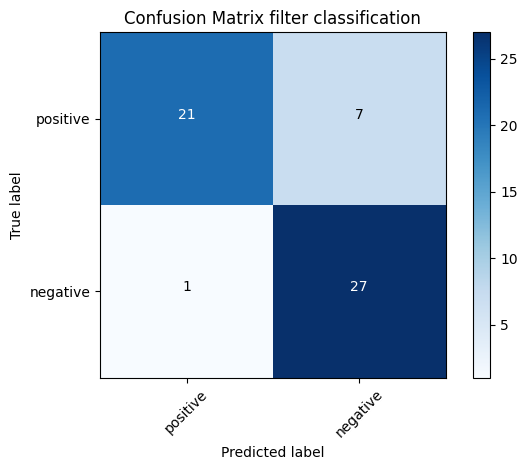

acc:  0.8571428571428571

precision: 
for positive:  0.9545454545454546
for negative:  0.7941176470588235

recall: 
for positive:  0.75
for negative:  0.9642857142857143


In [48]:
import matplotlib.pyplot as plt

def plotConfusionMatrix(cm, classNames, title):
    from sklearn.metrics import confusion_matrix
    import itertools

    classes = classNames
    plt.figure()
    plt.imshow(cm, interpolation = 'nearest', cmap = 'Blues')
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=45)
    plt.yticks(tick_marks, classNames)

    text_format = 'd'
    thresh = cm.max() / 2.
    for row, column in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(column, row, format(cm[row, column], text_format),
                horizontalalignment = 'center',
                color = 'white' if cm[row, column] > thresh else 'black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

    plt.show()

def evalMultiClass(realLabels, computedLabels, labelNames):
    from sklearn.metrics import confusion_matrix

    confMatrix = confusion_matrix(realLabels, computedLabels)
    acc = sum([confMatrix[i][i] for i in range(len(labelNames))]) / len(realLabels)
    precision = {}
    recall = {}
    for i in range(len(labelNames)):
        precision[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[j][i] for j in range(len(labelNames))])
        recall[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[i][j] for j in range(len(labelNames))])
    return acc, precision, recall, confMatrix


acc, prec, recall, cm = evalMultiClass(np.array(testOutputs), computedTestOutputs, labelNames)


plotConfusionMatrix(cm, labelNames, "filter classification")
print('acc: ', acc)

print('\nprecision: ')
print('for positive: ',prec['positive'])
print('for negative: ', prec['negative'])

print('\nrecall: ')
print('for positive: ',recall['positive'])
print('for negative: ', recall['negative'])